In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
df=pd.read_csv('../dataset/dataset_polymorphs_mp.csv')
# print(df.columns)
df2=df[df['reduced_formula']=='Li7Mn2(CoO4)3']
# print(df2.shape)



In [5]:
def plot_sg_distribution(df, nam, symb, im_name, formula=None):
    # ===== Figure 1: Space group distribution =====
    fig1, ax1 = plt.subplots(figsize=(6, 4))

    # Space group histogram with space group symbols
    sg_counts = df.groupby([nam, symb]).size().reset_index(name='count')
    sg_counts = sg_counts.sort_values('count', ascending=False).head(8)

    # Create counts dictionary - only include space groups that actually have structures
    sg_numbers = sg_counts[nam].tolist()
    y_values = sg_counts['count'].tolist()

    # Use sequential positions for even spacing
    x_positions = range(len(sg_numbers))

    # Plot bars
    ax1.bar(x_positions, y_values, color='white', edgecolor='red', linewidth=1.5, width=0.8)
    ax1.set_xlabel('Space Group Number', fontsize=12)
    ax1.set_ylabel('Number of structures', fontsize=12)
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels([str(int(sg)) for sg in sg_numbers], fontsize=10)
    ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax1.set_ylim(0, max(y_values) * 1.1 if y_values else 1)

    # Add chemical formula as title with subscripts if provided
    if formula is not None:
        # Convert numbers to subscripts using LaTeX
        import re
        def to_subscript(s):
            return re.sub(r'(\d+)', r'$_{\1}$', s)
        ax1.set_title(to_subscript(formula), fontsize=14)

    plt.tight_layout()
    # plt.savefig(f'{im_name}_space_group_distribution.png', dpi=250, bbox_inches='tight')
    plt.show()

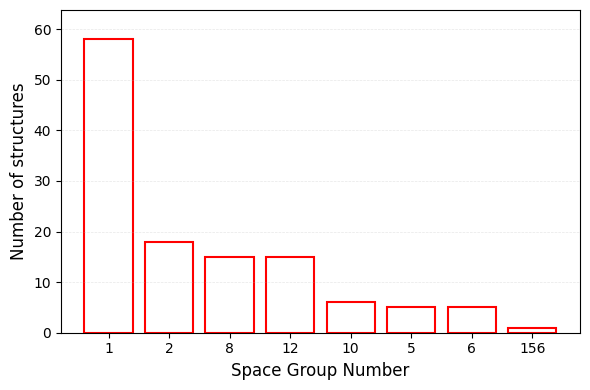

In [13]:
plot_sg_distribution(df2, 'sg_num','sg','Li7Mn2(CoO4)3')

In [15]:
df_icsd=pd.read_csv('../dataset/dataset_polymorphs_icsd.csv')
df_icsd=df_icsd[df_icsd['reduced_formula']=='SiO2']
df_icsd.shape

(196, 18)

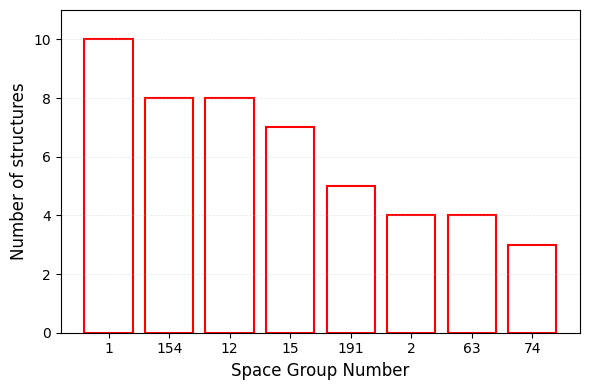

In [16]:
plot_sg_distribution(df_icsd, 'sg_number','sgr','SiO2')